In [99]:
import pandas as pd
import re

markdown_string = """
| TokenMixer | Kernel Size | ImageWoof              | PathMNIST                | DermaMNIST               | PneumoniaMNIST           | OrganSMNIST            |
|-------------|-------------|------------------------|--------------------------|--------------------------|--------------------------|------------------------|
| pooling     | 3           | 0.7908, 0.9495, 0.7907 | 0.8817, 0.9758, 0.8767   | 0.6828, 0.8883, 0.6868   | 0.9632, 0.9921, 0.9656   | 0.7659, 0.9617, 0.7689 |
|             | 5           | 0.7941, 0.9517, 0.7965 | 0.8832, 0.9799, 0.8773   | 0.6933, 0.8911, 0.6855   | 0.9393, 0.9832, 0.9446   | 0.7494, 0.9375, 0.7576 |
|             | 7           | 0.8044, 0.9539, 0.8059 | 0.903, 0.9829, 0.8986    | 0.6811, 0.8795, 0.6991   | 0.9526, 0.9814, 0.9537   | 0.7649, 0.942, 0.7706  |
| conv        | 3           | 0.7869, 0.9483, 0.7891 | 0.8862, 0.9834, 0.8814   | 0.7083, 0.8675, 0.7123   | 0.9064, 0.9761, 0.9201   | 0.7721, 0.9534, 0.7765 |
|             | 5           | 0.754, 0.9353, 0.7567  | 0.9045, 0.9878, 0.9035   | 0.7012, 0.8855, 0.7013   | 0.9419, 0.9807, 0.948    | 0.7695, 0.9475, 0.7743 |
|             | 7           | 0.7078, 0.9235, 0.709  | 0.9115, 0.9887, 0.9112   | 0.6883, 0.8628, 0.6872   | 0.95, 0.9925, 0.9535     | 0.7872, 0.9503, 0.7901 |
| grouped conv   | 3           | 0.7915, 0.9534, 0.7937 | 0.8888, 0.9803, 0.884    | 0.7138, 0.8867, 0.7029   | 0.9474, 0.9886, 0.9532   | 0.7837, 0.9535, 0.7863 |
|             | 5           | 0.7694, 0.9412, 0.7713 | 0.9068, 0.9821, 0.9065   | 0.7091, 0.8746, 0.7062   | 0.9534, 0.9863, 0.9569   | 0.7961, 0.941, 0.8001  |
|             | 7           | 0.7411, 0.9341, 0.7424 | 0.8927, 0.9798, 0.8884   | 0.6882, 0.8681, 0.7121   | 0.9521, 0.9878, 0.9552   | 0.785, 0.944, 0.7871   |
| locAttn   | 3           | 0.7357, 0.9152, 0.7371 | 0.858, 0.9701, 0.8476   | 0.7255, 0.8869, 0.7263  | 0.9521, 0.9739, 0.9521  | 0.7852, 0.9384, 0.7868 |
|             | 5           | 0.7203, 0.9104, 0.7206 | 0.8868, 0.9726, 0.8781  | 0.6999, 0.8538, 0.7199   | 0.9333, 0.978, 0.9408   | 0.783, 0.9274, 0.7875  |
|             | 7           | 0.6914, 0.9014, 0.6908 | 0.8794, 0.9782, 0.8728  | 0.692, 0.8458, 0.7081    | 0.9346, 0.9803, 0.9395 | 0.7826, 0.9326, 0.7866 |
| global attn  | -           | 0.5439, 0.8885, 0.5408 | 0.8778, 0.9802, 0.8647   | 0.6046, 0.9174, 0.5384   | 0.8688, 0.9493, 0.881    | 0.7357, 0.9679, 0.741  |
| random      | -           | 0.79, 0.96, 0.7911     | 0.9072, 0.9805, 0.9039   | 0.707, 0.9024, 0.723     | 0.9594, 0.9863, 0.9637   | 0.7709, 0.9461, 0.7731 |
| identity    | 1           | 0.7695, 0.9575, 0.7698 | 0.8913, 0.9756, 0.8822   | 0.6722, 0.8784, 0.6761   | 0.9432, 0.9883, 0.9466   | 0.7687, 0.9626, 0.772  |
| ResNet18    | 3           | 0.7454, 0.9381, 0.7478 | 0.8392, 0.9735, 0.826    | 0.7332, 0.9135, 0.7388   | 0.8885, 0.8885, 0.9048   | 0.7866, 0.9627, 0.7904 |
|             | 5           | 0.7257, 0.9355, 0.7271 | 0.8732, 0.9735, 0.8615   | 0.7002, 0.8772, 0.7331   | 0.9308, 0.9833, 0.9404   | 0.7836, 0.9558, 0.7907 |
|             | 7           | 0.6909, 0.9165, 0.6928 | 0.8619, 0.9772, 0.8496   | 0.6912, 0.8639, 0.7015   | 0.9124, 0.9868, 0.9241   | 0.7763, 0.9378, 0.7832 |
"""

lines = markdown_string.split("\n")
header = lines[1].strip("|").split("|")
header = list(map(lambda s: s.strip(), header))

data = []

# Loop through lines starting from 2
for line in lines[3:]:

    # Break once we hit an empty line
    if not line.strip():
        break

    cols = line.strip("|").split("|")
    cols = map(lambda s: s.strip(), cols)
    row = dict(zip(header, cols))
    data.append(row)

df = pd.DataFrame(data)
df.iloc[:, 0] = df.iloc[:, 0].replace("", pd.NA).ffill()
df.set_index(['TokenMixer', 'Kernel Size'], inplace=True)

df_split = df.apply(lambda col: col.str.split(","))
df_expanded = pd.concat(
    [df_split[col].apply(pd.Series).add_prefix(f"{col.strip()}_") for col in df_split.columns],
    axis=1
)

suffix_map = {
    "_0": "_acc",
    "_1": "_auc",
    "_2": "_f1"
}
df = df_expanded.rename(columns=lambda col: next((col.replace(k, v) for k, v in suffix_map.items() if k in col), col))
df = df.apply(pd.to_numeric, errors="coerce")
# df.to_pickle('classification_4t_scratch.pkl')

# drop resnet and other metrics
df_rank = df.loc[~df.index.get_level_values(0).str.startswith('ResNet'), df.columns.str.endswith('_auc')]
df_rank = df_rank.rank(axis=0, ascending=False, method="first")
df_rank_no_imgwoof = df_rank.iloc[:, 1:]

df_rank


ImageWoof_auc  PathMNIST_auc  DermaMNIST_auc  \
TokenMixer   Kernel Size                                                 
pooling      3                      6.0           12.0             4.0   
             5                      5.0            9.0             3.0   
             7                      3.0            4.0             8.0   
conv         3                      7.0            3.0            12.0   
             5                      9.0            2.0             7.0   
             7                     11.0            1.0            13.0   
grouped conv 3                      4.0            7.0             6.0   
             5                      8.0            5.0            10.0   
             7                     10.0           10.0            11.0   
locAttn      3                     12.0           15.0             5.0   
             5                     13.0           14.0            14.0   
             7                     14.0           11.0            15.0   
global attn  -                     15.0            8.0             1.0   
random       -                      1.0            6.0             2.0   
identity     1                      2.0           13.0             9.0   

                          PneumoniaMNIST_auc  OrganSMNIST_auc  
TokenMixer   Kernel Size                                       
pooling      3                           2.0              3.0  
             5                           8.0             13.0  
             7                           9.0             10.0  
conv         3                          13.0              5.0  
             5                          10.0              7.0  
             7                           1.0              6.0  
grouped conv 3                           3.0              4.0  
             5                           6.0             11.0  
             7                           5.0              9.0  
locAttn      3                          14.0             12.0  
             5                          12.0             15.0  
             7                          11.0             14.0  
global attn  -                          15.0              1.0  
random       -                           7.0              8.0  
identity     1                           4.0              2.0

# Global Rank

In [100]:
df_rank.mean(1).sort_values()

TokenMixer    Kernel Size
grouped conv  3               4.8
random        -               4.8
pooling       3               5.4
identity      1               6.0
conv          7               6.4
pooling       7               6.8
conv          5               7.0
pooling       5               7.6
grouped conv  5               8.0
conv          3               8.0
global attn   -               8.0
grouped conv  7               9.0
locAttn       3              11.6
              7              13.0
              5              13.6
dtype: float64

In [101]:
df_rank_no_imgwoof.mean(1).sort_values()

TokenMixer    Kernel Size
grouped conv  3               5.00
pooling       3               5.25
conv          7               5.25
random        -               5.75
global attn   -               6.25
conv          5               6.50
identity      1               7.00
pooling       7               7.75
grouped conv  5               8.00
conv          3               8.25
pooling       5               8.25
grouped conv  7               8.75
locAttn       3              11.50
              7              12.75
              5              13.75
dtype: float64

# Pool Size ranking

In [102]:
df_rank.groupby('Kernel Size').mean()

,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
Kernel Size,,,,,
-,8.00,7.00,1.50,11.0,4.50
1,2.00,13.00,9.00,4.0,2.00
3,7.25,9.25,6.75,8.0,6.00
5,8.75,7.50,8.50,9.0,11.50
7,9.50,6.50,11.75,6.5,9.75


In [103]:
df_rank.groupby('Kernel Size').mean().mean(1).sort_values()

Kernel Size
1    6.00
-    6.40
3    7.45
7    8.80
5    9.05
dtype: float64

In [104]:
df_rank_no_imgwoof.groupby('Kernel Size').mean().mean(1).sort_values()

Kernel Size
-    6.000
1    7.000
3    7.500
7    8.625
5    9.125
dtype: float64

# Token Mixer

In [105]:
df_rank.groupby('TokenMixer').mean()

,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
TokenMixer,,,,,
conv,9.000000,2.000000,10.666667,8.000000,6.000000
global attn,15.000000,8.000000,1.000000,15.000000,1.000000
grouped conv,7.333333,7.333333,9.000000,4.666667,8.000000
identity,2.000000,13.000000,9.000000,4.000000,2.000000
locAttn,13.000000,13.333333,11.333333,12.333333,13.666667
pooling,4.666667,8.333333,5.000000,6.333333,8.666667
random,1.000000,6.000000,2.000000,7.000000,8.000000


In [106]:
df_rank.groupby('TokenMixer').mean().mean(1).sort_values()

TokenMixer
random           4.800000
identity         6.000000
pooling          6.600000
conv             7.133333
grouped conv     7.266667
global attn      8.000000
locAttn         12.733333
dtype: float64

In [107]:
df_rank_no_imgwoof.groupby('TokenMixer').mean().mean(1).sort_values()

TokenMixer
random           5.750000
global attn      6.250000
conv             6.666667
identity         7.000000
pooling          7.083333
grouped conv     7.250000
locAttn         12.666667
dtype: float64

In [108]:
df_print = df.loc[:, df.columns.str.endswith('_auc')]
df_print = df_print.rename(columns=lambda s: s[:-4])
df_print = df_print.style.format(precision=4)
print(df_print.to_latex())

\begin{tabular}{llrrrrr}
 &  & ImageWoof & PathMNIST & DermaMNIST & PneumoniaMNIST & OrganSMNIST \\
TokenMixer & Kernel Size &  &  &  &  &  \\
\multirow[c]{3}{*}{pooling} & 3 & 0.9495 & 0.9758 & 0.8883 & 0.9921 & 0.9617 \\
 & 5 & 0.9517 & 0.9799 & 0.8911 & 0.9832 & 0.9375 \\
 & 7 & 0.9539 & 0.9829 & 0.8795 & 0.9814 & 0.9420 \\
\multirow[c]{3}{*}{conv} & 3 & 0.9483 & 0.9834 & 0.8675 & 0.9761 & 0.9534 \\
 & 5 & 0.9353 & 0.9878 & 0.8855 & 0.9807 & 0.9475 \\
 & 7 & 0.9235 & 0.9887 & 0.8628 & 0.9925 & 0.9503 \\
\multirow[c]{3}{*}{grouped conv} & 3 & 0.9534 & 0.9803 & 0.8867 & 0.9886 & 0.9535 \\
 & 5 & 0.9412 & 0.9821 & 0.8746 & 0.9863 & 0.9410 \\
 & 7 & 0.9341 & 0.9798 & 0.8681 & 0.9878 & 0.9440 \\
\multirow[c]{3}{*}{locAttn} & 3 & 0.9152 & 0.9701 & 0.8869 & 0.9739 & 0.9384 \\
 & 5 & 0.9104 & 0.9726 & 0.8538 & 0.9780 & 0.9274 \\
 & 7 & 0.9014 & 0.9782 & 0.8458 & 0.9803 & 0.9326 \\
global attn & - & 0.8885 & 0.9802 & 0.9174 & 0.9493 & 0.9679 \\
random & - & 0.9600 & 0.9805 & 0.9024 & 0.9863 

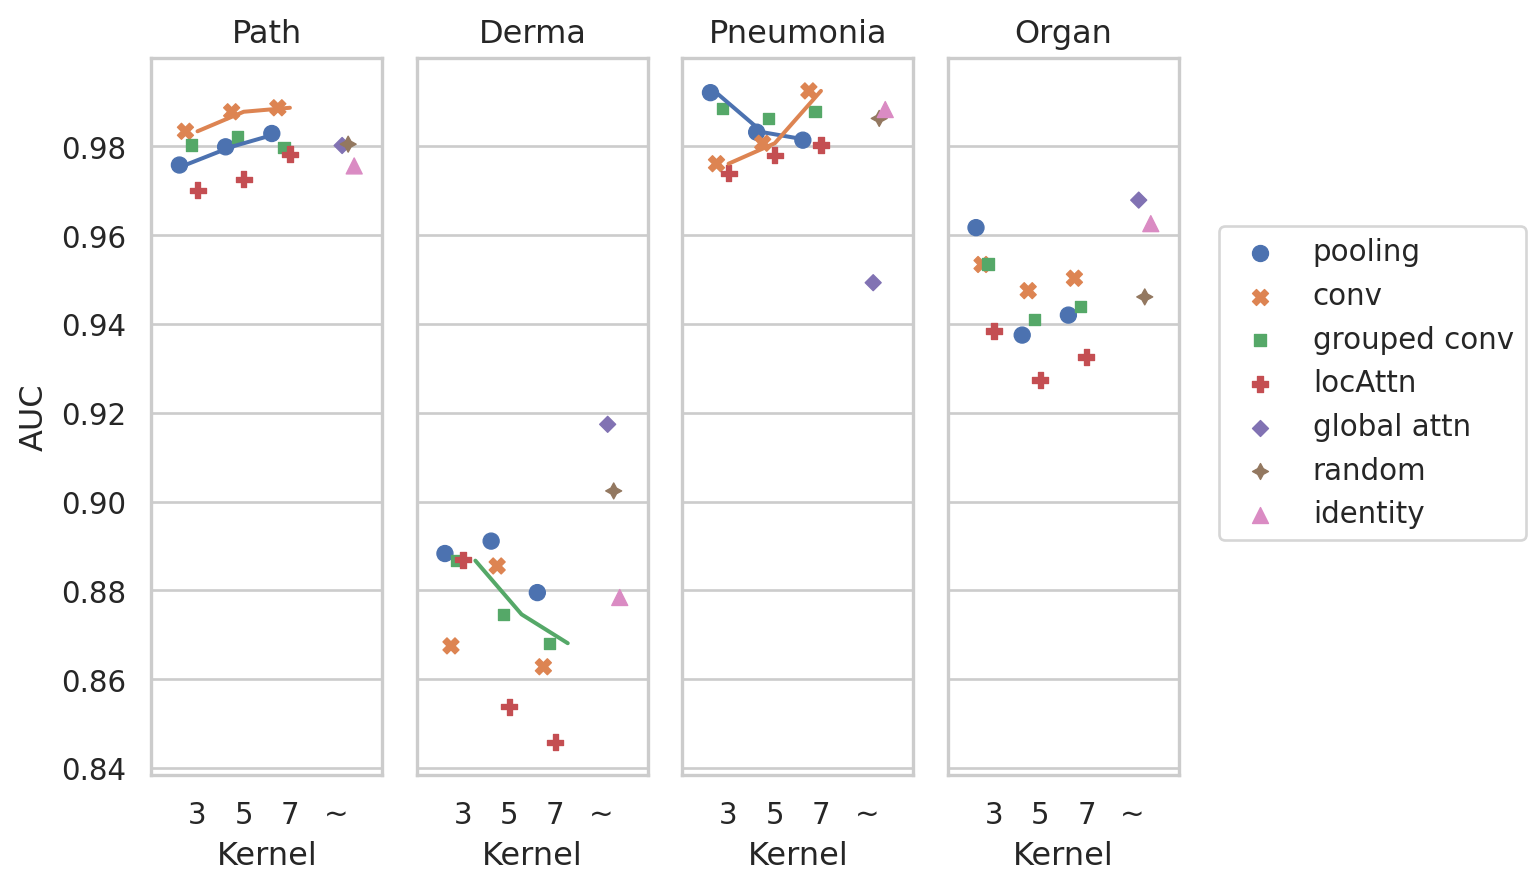

In [109]:
from seaborn import objects as so
import seaborn as sns

df_long = df.loc[:,~df.columns.str.startswith('ImageWoof') & df.columns.str.endswith('_auc')]
df_long.columns = df_long.columns.str.rstrip('_auc')
df_long.columns = df_long.columns.str.rstrip('MNIST')
df_long = df_long.loc[~df_long.index.get_level_values(0).str.startswith('ResNet')]
df_long = df_long.reset_index().melt(id_vars=["TokenMixer", "Kernel Size"], var_name="dataset", value_name="auc")
df_long.loc[df_long['Kernel Size'].isin(['1', '-']), 'Kernel Size'] = '~'

df_lines = df_long.query(' or '.join([
    "dataset == 'Path' and TokenMixer.isin(['pooling', 'local attn', 'conv'])",
    "dataset == 'Derma' and TokenMixer.isin(['local attn', 'grouped conv'])",
    "dataset == 'Pneumonia' and TokenMixer.isin(['local attn', 'conv', 'pooling'])",
]))

(
    so.Plot(df_long, x="Kernel Size", y="auc", color="TokenMixer")
    .facet(col="dataset")
    .theme(sns.axes_style("whitegrid"))
    .add(so.Line(), so.Dodge(), data=df_lines, legend=False)
    .add(so.Dot(), so.Dodge(), marker='TokenMixer')
    .limit(x=(-1, 4))
    .layout(engine='tight')
    .label(x='Kernel', y='AUC', color='')
    .save(f'4t_scratch.pdf', dpi=450, bbox_inches='tight')
)

In [110]:
df_print = df.loc[:, ~df.columns.str.endswith('_auc')]
df_print = df_print.style.format(precision=4)
print(df_print.to_latex())

\begin{tabular}{llrrrrrrrrrr}
 &  & ImageWoof_acc & ImageWoof_f1 & PathMNIST_acc & PathMNIST_f1 & DermaMNIST_acc & DermaMNIST_f1 & PneumoniaMNIST_acc & PneumoniaMNIST_f1 & OrganSMNIST_acc & OrganSMNIST_f1 \\
TokenMixer & Kernel Size &  &  &  &  &  &  &  &  &  &  \\
\multirow[c]{3}{*}{pooling} & 3 & 0.7908 & 0.7907 & 0.8817 & 0.8767 & 0.6828 & 0.6868 & 0.9632 & 0.9656 & 0.7659 & 0.7689 \\
 & 5 & 0.7941 & 0.7965 & 0.8832 & 0.8773 & 0.6933 & 0.6855 & 0.9393 & 0.9446 & 0.7494 & 0.7576 \\
 & 7 & 0.8044 & 0.8059 & 0.9030 & 0.8986 & 0.6811 & 0.6991 & 0.9526 & 0.9537 & 0.7649 & 0.7706 \\
\multirow[c]{3}{*}{conv} & 3 & 0.7869 & 0.7891 & 0.8862 & 0.8814 & 0.7083 & 0.7123 & 0.9064 & 0.9201 & 0.7721 & 0.7765 \\
 & 5 & 0.7540 & 0.7567 & 0.9045 & 0.9035 & 0.7012 & 0.7013 & 0.9419 & 0.9480 & 0.7695 & 0.7743 \\
 & 7 & 0.7078 & 0.7090 & 0.9115 & 0.9112 & 0.6883 & 0.6872 & 0.9500 & 0.9535 & 0.7872 & 0.7901 \\
\multirow[c]{3}{*}{grouped conv} & 3 & 0.7915 & 0.7937 & 0.8888 & 0.8840 & 0.7138 & 0.7029 & 0.